# Problem 1

In [93]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.neighbors import KNeighborsClassifier

In [94]:
data = pd.read_csv("spambase.data", header=None)
X = data.iloc[:, :-1]
y = data.iloc[:, -1]
# 25% testing, 75% training 
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42
)


In [95]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

def compute_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    error = 1 - acc
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    
    return acc, error, precision, recall

In [96]:
from sklearn.linear_model import LogisticRegression

# Create and fit the model
model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)

# Predict on training and test sets
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Compute metrics using the helper function
log_train_metrics = compute_metrics(y_train, y_train_pred)
log_test_metrics = compute_metrics(y_test, y_test_pred)

print("Logistic Regression Train Metrics (Accuracy, Error, Precision, Recall):")
print(log_train_metrics)

print("Logistic Regression Test Metrics (Accuracy, Error, Precision, Recall):")
print(log_test_metrics)

Logistic Regression Train Metrics (Accuracy, Error, Precision, Recall):
(0.9289855072463769, 0.07101449275362315, 0.9266198282591726, 0.8871449925261584)
Logistic Regression Test Metrics (Accuracy, Error, Precision, Recall):
(0.9304952215464813, 0.06950477845351866, 0.9438202247191011, 0.8842105263157894)


In [97]:
# metrics must be calulated on the test set
cm = confusion_matrix(y_test, y_test_pred)
print(cm)

[[651  25]
 [ 55 420]]


In [98]:
accuracy = accuracy_score(y_test, y_test_pred)
error = 1- accuracy
print("Accuracy:", accuracy)
print("Error:", error)

Accuracy: 0.9304952215464813
Error: 0.06950477845351866


In [99]:
pre_score = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)

# Of the emails the model predicted as spam, how many were actually spam?
print("Precision:", pre_score)
# Of all the actual spam emails, how many did the model successfully detect
print("Recall:", recall)
print("F1 Score:", f1)

Precision: 0.9438202247191011
Recall: 0.8842105263157894
F1 Score: 0.9130434782608695


In [100]:
coefficients = model.coef_[0]
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": coefficients
})
coef_df

,Feature,Coefficient
0,0,-0.245245
1,1,-0.129602
2,2,0.143007
3,3,0.753779
4,4,0.632383
5,5,0.650266
6,6,2.113741
7,7,0.499704
8,8,0.605978
9,9,0.077974


In [101]:
coef_df["abs_coef"] = coef_df["Coefficient"].abs()
important_features = coef_df.sort_values(by="abs_coef", ascending=False)

important_features.head(10)

,Feature,Coefficient,abs_coef
26,26,-4.200692,4.200692
52,52,3.480035,3.480035
22,22,2.135519,2.135519
6,6,2.113741,2.113741
24,24,-1.817970,1.817970
47,47,-1.790171,1.790171
43,43,-1.727097,1.727097
41,41,-1.533044,1.533044
14,14,1.516684,1.516684
40,40,-1.345561,1.345561


In [102]:
coef_df.sort_values(by="Coefficient", ascending=False).head(10)

,Feature,Coefficient,abs_coef
52,52,3.480035,3.480035
22,22,2.135519,2.135519
6,6,2.113741,2.113741
14,14,1.516684,1.516684
53,53,1.156040,1.156040
15,15,1.010851,1.010851
35,35,0.982363,0.982363
19,19,0.904506,0.904506
16,16,0.885321,0.885321
3,3,0.753779,0.753779


In [103]:
thresholds = [0.25, 0.5, 0.75, 0.9]
y_probs = model.predict_proba(X_test)[:, 1]
results = []
for T in thresholds:
    y_pred_thresh = (y_probs >= T).astype(int)
    acc = accuracy_score(y_test, y_pred_thresh)
    prec = precision_score(y_test, y_pred_thresh)
    rec = recall_score(y_test, y_pred_thresh)
    
    results.append((T, acc, prec, rec))

results_df = pd.DataFrame(results, columns=["Threshold", "Accuracy", "Precision", "Recall"])
results_df

,Threshold,Accuracy,Precision,Recall
0,0.25,0.907037,0.838235,0.960000
1,0.50,0.930495,0.943820,0.884211
2,0.75,0.886186,0.957447,0.757895
3,0.90,0.823632,0.972222,0.589474


# Problem 2

In [104]:
learning_rates = [0.01, 0.1, 0.5]
def sigmoid(z):
    return 1 / (1+np.exp(-z))

def logistic_regression_gradient_descent(X, y, lr, num_iters = 100):
    # add bias column to feature matrix
    X = np.hstack([np.ones((X.shape[0], 1)), X])
    n,d = X.shape
    w = np.zeros(d)
    losses = {}
    # training loop, 1-num_iters
    for i in range(1, num_iters+1):
        z = X @ w
        y_hat = sigmoid(z)
        # Avoid log(0)
        y_hat = np.clip(y_hat, 1e-10, 1 - 1e-10)

        # loss function
        loss = -np.mean(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))
        if i in [10, 50, 100]:
            losses[i] = loss
        
        # compute gradient 
        grad = (1/n) * X.T @ (y_hat - y)

        w = w -lr * grad
    return w, losses

def predict(X, w, threshold = 0.5):
    X = np.hstack([np.ones((X.shape[0], 1)), X])
    probs = sigmoid(X @ w)
    return (probs >= threshold).astype(int)




In [105]:
learning_rates = [0.01, 0.1, 0.5]

results = []

for lr in learning_rates:
    w, losses = logistic_regression_gradient_descent(X_train.values, y_train.values, lr)
    
    # Predictions on test set
    y_pred = predict(X_test.values, w)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results.append({
        "Learning Rate": lr,
        "Loss @100": losses[100],
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1
    })

results_df = pd.DataFrame(results)
results_df

/var/folders/rp/k71gjbcn2434_dm39cqcw5m80000gn/T/ipykernel_29590/2172793273.py:3: RuntimeWarning: overflow encountered in exp
  return 1 / (1+np.exp(-z))
/var/folders/rp/k71gjbcn2434_dm39cqcw5m80000gn/T/ipykernel_29590/2172793273.py:3: RuntimeWarning: overflow encountered in exp
  return 1 / (1+np.exp(-z))
/var/folders/rp/k71gjbcn2434_dm39cqcw5m80000gn/T/ipykernel_29590/2172793273.py:3: RuntimeWarning: overflow encountered in exp
  return 1 / (1+np.exp(-z))


,Learning Rate,Loss @100,Accuracy,Precision,Recall,F1
0,0.01,5.424441,0.629887,0.621891,0.263158,0.369822
1,0.10,12.264554,0.598610,1.000000,0.027368,0.053279
2,0.50,13.177863,0.611642,0.769231,0.084211,0.151803


# Problem 3

In [106]:
import numpy as np
from sklearn.model_selection import KFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score

def compute_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    error = 1 - acc
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    return acc, error, precision, recall

k_values = [1, 3, 5, 7, 9, 11, 15, 20]
kf = KFold(n_splits=5, shuffle=True, random_state=42)

results = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)

    acc_scores = []
    prec_scores = []
    rec_scores = []

    for train_idx, val_idx in kf.split(X_train):
        X_tr = X_train.iloc[train_idx]
        X_val = X_train.iloc[val_idx]
        y_tr = y_train.iloc[train_idx]
        y_val = y_train.iloc[val_idx]

        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_val)

        acc_scores.append(accuracy_score(y_val, y_pred))
        prec_scores.append(precision_score(y_val, y_pred, zero_division=0))
        rec_scores.append(recall_score(y_val, y_pred, zero_division=0))

    avg_acc = np.mean(acc_scores)
    avg_error = 1 - avg_acc
    avg_prec = np.mean(prec_scores)
    avg_rec = np.mean(rec_scores)

    results.append((k, avg_acc, avg_error, avg_prec, avg_rec))

print("k | Accuracy | Error | Precision | Recall")
for r in results:
    print(f"{r[0]:2d} | {r[1]:.4f} | {r[2]:.4f} | {r[3]:.4f} | {r[4]:.4f}")

best_k = min(results, key=lambda x: x[2])[0]
print("\nBest k:", best_k)

knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train, y_train)

y_train_pred_knn = knn.predict(X_train)
knn_train_metrics = compute_metrics(y_train, y_train_pred_knn)

print("\nkNN Train Metrics (Accuracy, Error, Precision, Recall):")
print(knn_train_metrics)

y_test_pred_knn = knn.predict(X_test)
knn_test_metrics = compute_metrics(y_test, y_test_pred_knn)

print("\nkNN Test Metrics (Accuracy, Error, Precision, Recall):")
print(knn_test_metrics)

k | Accuracy | Error | Precision | Recall
 1 | 0.8029 | 0.1971 | 0.7470 | 0.7449
 3 | 0.8055 | 0.1945 | 0.7567 | 0.7349
 5 | 0.8009 | 0.1991 | 0.7570 | 0.7160
 7 | 0.7983 | 0.2017 | 0.7550 | 0.7105
 9 | 0.7919 | 0.2081 | 0.7461 | 0.7028
11 | 0.7890 | 0.2110 | 0.7433 | 0.6966
15 | 0.7783 | 0.2217 | 0.7233 | 0.6931
20 | 0.7681 | 0.2319 | 0.7234 | 0.6510

Best k: 3

kNN Train Metrics (Accuracy, Error, Precision, Recall):
(0.9017391304347826, 0.0982608695652174, 0.8869093725793958, 0.8557548579970105)

kNN Test Metrics (Accuracy, Error, Precision, Recall):
(0.7827975673327541, 0.21720243266724593, 0.7551020408163265, 0.7010526315789474)


In [107]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)

,"solver solver: {'svd', 'lsqr', 'eigen'}, default='svd'Solver to use, possible values: - 'svd': Singular value decomposition (default). Does not compute the covariance matrix, therefore this solver is recommended for data with a large number of features. - 'lsqr': Least squares solution. Can be combined with shrinkage or custom covariance estimator. - 'eigen': Eigenvalue decomposition. Can be combined with shrinkage or custom covariance estimator... versionchanged:: 1.2 `solver=""svd""` now has experimental Array API support. See the :ref:`Array API User Guide ` for more details.",'svd'
,"shrinkage shrinkage: 'auto' or float, default=NoneShrinkage parameter, possible values: - None: no shrinkage (default). - 'auto': automatic shrinkage using the Ledoit-Wolf lemma. - float between 0 and 1: fixed shrinkage parameter.This should be left to None if `covariance_estimator` is used.Note that shrinkage works only with 'lsqr' and 'eigen' solvers.For a usage example, see:ref:`sphx_glr_auto_examples_classification_plot_lda.py`.",None
,"priors priors: array-like of shape (n_classes,), default=NoneThe class prior probabilities. By default, the class proportions areinferred from the training data.",None
,"n_components n_components: int, default=NoneNumber of components (<= min(n_classes - 1, n_features)) fordimensionality reduction. If None, will be set tomin(n_classes - 1, n_features). This parameter only affects the`transform` method.For a usage example, see:ref:`sphx_glr_auto_examples_decomposition_plot_pca_vs_lda.py`.",None
,"store_covariance store_covariance: bool, default=FalseIf True, explicitly compute the weighted within-class covariancematrix when solver is 'svd'. The matrix is always computedand stored for the other solvers... versionadded:: 0.17",False
,"tol tol: float, default=1.0e-4Absolute threshold for a singular value of X to be consideredsignificant, used to estimate the rank of X. Dimensions whosesingular values are non-significant are discarded. Only used ifsolver is 'svd'... versionadded:: 0.17",0.0001
,"covariance_estimator covariance_estimator: covariance estimator, default=NoneIf not None, `covariance_estimator` is used to estimatethe covariance matrices instead of relying on the empiricalcovariance estimator (with potential shrinkage).The object should have a fit method and a ``covariance_`` attributelike the estimators in :mod:`sklearn.covariance`.if None the shrinkage parameter drives the estimate.This should be left to None if `shrinkage` is used.Note that `covariance_estimator` works only with 'lsqr' and 'eigen'solvers... versionadded:: 0.24",None


In [108]:
y_train_pred_lda = lda.predict(X_train)
y_test_pred_lda = lda.predict(X_test)

In [109]:
lda_train_metrics = compute_metrics(y_train, y_train_pred_lda)
lda_test_metrics = compute_metrics(y_test, y_test_pred_lda)

print("LDA Train:  Accuracy, Error, Precision, Recall")
print(lda_train_metrics)

print("\nLDA Test:  Accuracy, Error, Precision, Recall")
print(lda_test_metrics)

LDA Train:  Accuracy, Error, Precision, Recall
(0.8866666666666667, 0.11333333333333329, 0.9157155399473222, 0.7795216741405082)

LDA Test:  Accuracy, Error, Precision, Recall
(0.8853171155516942, 0.11468288444830577, 0.9298245614035088, 0.7810526315789473)


In [ ]:
models = ["Logistic Regression", "LDA", "kNN"]

train_results = [
    log_train_metrics,
    lda_train_metrics,
    knn_train_metrics
]

test_results = [
    log_test_metrics,
    lda_test_metrics,
    knn_test_metrics
]

print("TRAIN RESULTS")
for m, r in zip(models, train_results):
    print(f"{m}: Acc={r[0]:.4f}, Err={r[1]:.4f}, Prec={r[2]:.4f}, Rec={r[3]:.4f}")

print("\nTEST RESULTS")
for m, r in zip(models, test_results):
    print(f"{m}: Acc={r[0]:.4f}, Err={r[1]:.4f}, Prec={r[2]:.4f}, Rec={r[3]:.4f}")

=== TRAIN RESULTS ===
Logistic Regression: Acc=0.9290, Err=0.0710, Prec=0.9266, Rec=0.8871
LDA: Acc=0.8867, Err=0.1133, Prec=0.9157, Rec=0.7795
kNN: Acc=0.9017, Err=0.0983, Prec=0.8869, Rec=0.8558

=== TEST RESULTS ===
Logistic Regression: Acc=0.9305, Err=0.0695, Prec=0.9438, Rec=0.8842
LDA: Acc=0.8853, Err=0.1147, Prec=0.9298, Rec=0.7811
kNN: Acc=0.7828, Err=0.2172, Prec=0.7551, Rec=0.7011


Matplotlib is building the font cache; this may take a moment.


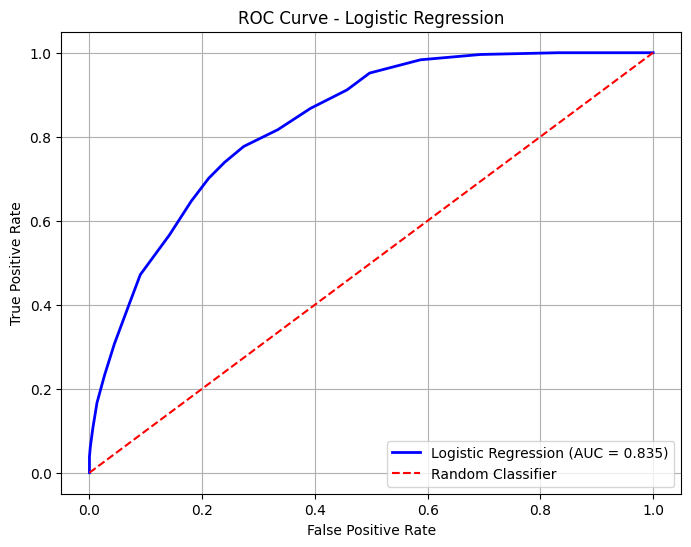

AUC for Logistic Regression on test set: 0.835


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Get predicted probabilities for the positive class 
y_prob = model.predict_proba(X_test)[:, 1]

# Compute false positive rate, true positive rate , and thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Compute Area Under the Curve 
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'Logistic Regression (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print(f"AUC for Logistic Regression on test set: {roc_auc:.3f}")

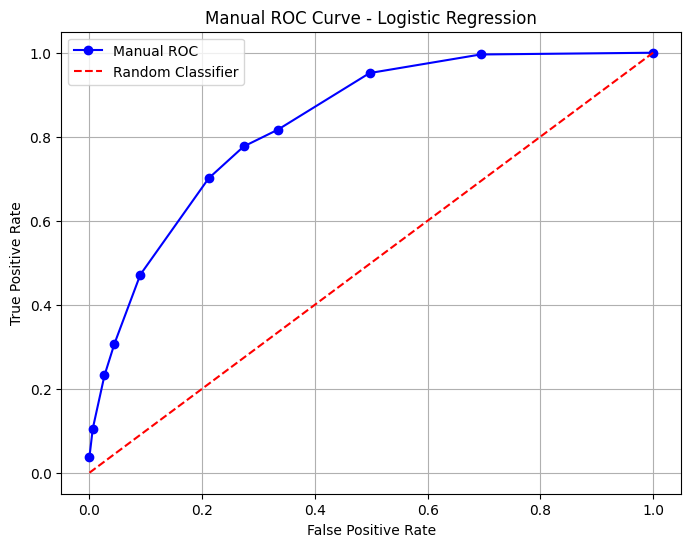

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

y_prob = model.predict_proba(X_test)[:, 1]

# Define thresholds
thresholds = np.arange(0, 1.1, 0.1)

tpr_list = []
fpr_list = []

for T in thresholds:
    # Predict positive if probability >= threshold, else negative
    y_pred_thresh = (y_prob >= T).astype(int)
    
    # True Positives, False Positives, False Negatives, True Negatives
    TP = np.sum((y_test == 1) & (y_pred_thresh == 1))
    FP = np.sum((y_test == 0) & (y_pred_thresh == 1))
    FN = np.sum((y_test == 1) & (y_pred_thresh == 0))
    TN = np.sum((y_test == 0) & (y_pred_thresh == 0))
    
    # Compute TPR and FPR
    TPR = TP / (TP + FN) if (TP + FN) != 0 else 0
    FPR = FP / (FP + TN) if (FP + TN) != 0 else 0
    
    tpr_list.append(TPR)
    fpr_list.append(FPR)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_list, tpr_list, marker='o', color='blue', label='Manual ROC')
plt.plot([0,1], [0,1], linestyle='--', color='red', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Manual ROC Curve - Logistic Regression')
plt.grid(True)
plt.legend()
plt.show()

# Problem 4

In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

def k_fold_cv(X, y, model_class, k=5, **model_kwargs):
    n_samples = X.shape[0]
    indices = np.arange(n_samples)
    np.random.shuffle(indices)  # shuffle indices for randomness
    
    fold_sizes = np.full(k, n_samples // k, dtype=int)  # basic equal split
    fold_sizes[:n_samples % k] += 1  # distribute remainder
    
    current = 0
    errors = []
    
    for fold_size in fold_sizes:
        val_idx = indices[current:current+fold_size]
        train_idx = np.concatenate([indices[:current], indices[current+fold_size:]])
        current += fold_size
        
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        
        model = model_class(**model_kwargs)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)
        
        # Validation error
        val_error = np.mean(y_pred != y_val)
        errors.append(val_error)
    
    avg_error = np.mean(errors)
    return avg_error, errors
k = 5

# Logistic Regression
log_avg_error, log_errors = k_fold_cv(X.values, y.values, LogisticRegression, k=k, max_iter=5000)
print("Logistic Regression CV Errors per fold:", log_errors)
print("Logistic Regression Average CV Error:", log_avg_error)

# LDA
lda_avg_error, lda_errors = k_fold_cv(X.values, y.values, LinearDiscriminantAnalysis, k=k)
print("LDA CV Errors per fold:", lda_errors)
print("LDA Average CV Error:", lda_avg_error)

Logistic Regression CV Errors per fold: [np.float64(0.07057546145494029), np.float64(0.08152173913043478), np.float64(0.07282608695652174), np.float64(0.06847826086956521), np.float64(0.0782608695652174)]
Logistic Regression Average CV Error: 0.07433248359533588
LDA CV Errors per fold: [np.float64(0.11834961997828447), np.float64(0.10869565217391304), np.float64(0.11630434782608695), np.float64(0.13043478260869565), np.float64(0.09130434782608696)]
LDA Average CV Error: 0.11301775008261342


In [ ]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

k_values = [5, 10]

cv_results = {}

for k in k_values:
    log_avg_error, log_errors = k_fold_cv(X.values, y.values, LogisticRegression, k=k, max_iter=5000)
    
    lda_avg_error, lda_errors = k_fold_cv(X.values, y.values, LinearDiscriminantAnalysis, k=k)
    
    cv_results[k] = {
        "LogisticRegression": log_avg_error,
        "LDA": lda_avg_error
    }

for k in k_values:
    print(f"{k}-Fold Cross Validation")
    print(f"Logistic Regression Average Validation Error: {cv_results[k]['LogisticRegression']:.4f}")
    print(f"LDA Average Validation Error: {cv_results[k]['LDA']:.4f}\n")

=== 5-Fold Cross Validation ===
Logistic Regression Average Validation Error: 0.0722
LDA Average Validation Error: 0.1126

=== 10-Fold Cross Validation ===
Logistic Regression Average Validation Error: 0.0726
LDA Average Validation Error: 0.1124

